# attention in transformers demo
## rutgers ieee ml/ai workshop by mehek 👽

week 3 of natural language processing track

march 4, 2026


## install packages




In [ ]:
!pip install transformers -q

import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from transformers import GPT2Tokenizer, GPT2Model
from IPython.display import display, HTML

## load gpt-2

In [ ]:
# Load tokenizer and model
# output_attentions=True tells the model to return attention weights
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model     = GPT2Model.from_pretrained('gpt2', output_attentions=True)
model.eval()  # inference mode, no gradients

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'GPT-2 loaded: {total_params:,} parameters')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 loaded: 124,439,808 parameters


## tokenize


gpt-2 uses **byte pair encoding (BPE)**.
common words have their own token (in the vocabulary). and more rare words get split into subword pieces.

In [ ]:
sentence = "i like cheese and crackers"

# tokenize
inputs    = tokenizer(sentence, return_tensors='pt')
input_ids = inputs['input_ids']  # shape: [1, seq_len]

# decode each token individually for the mapping
tokens = [tokenizer.decode([tok_id]) for tok_id in input_ids[0]]

print(f'Sentence : "{sentence}"')
print(f'Token IDs: {input_ids[0].tolist()}')
print(f'Tokens   : {tokens}')
print(f'Sequence length: {len(tokens)} tokens')
print()
# each token ID is a row index into the 50,257-row embedding table

Sentence : "i like cheese and crackers"
Token IDs: [72, 588, 9891, 290, 8469, 364]
Tokens   : ['i', ' like', ' cheese', ' and', ' crack', 'ers']
Sequence length: 6 tokens



## run and collect attention matrices

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions is a tuple of tensors, one per layer
attentions = outputs.attentions

print(f'Number of layers     : {len(attentions)}')
print(f'Shape per layer      : {attentions[0].shape}')
print(f'  → [batch={attentions[0].shape[0]}, heads={attentions[0].shape[1]}, seq={attentions[0].shape[2]}, seq={attentions[0].shape[3]}]')
print()
print('Each [seq x seq] matrix = softmax(Q·Kᵀ / sqrt(d_k)) for one head')

Number of layers     : 12
Shape per layer      : torch.Size([1, 12, 6, 6])
  → [batch=1, heads=12, seq=6, seq=6]

Each [seq x seq] matrix = softmax(Q·Kᵀ / sqrt(d_k)) for one head


## visualize an attention head

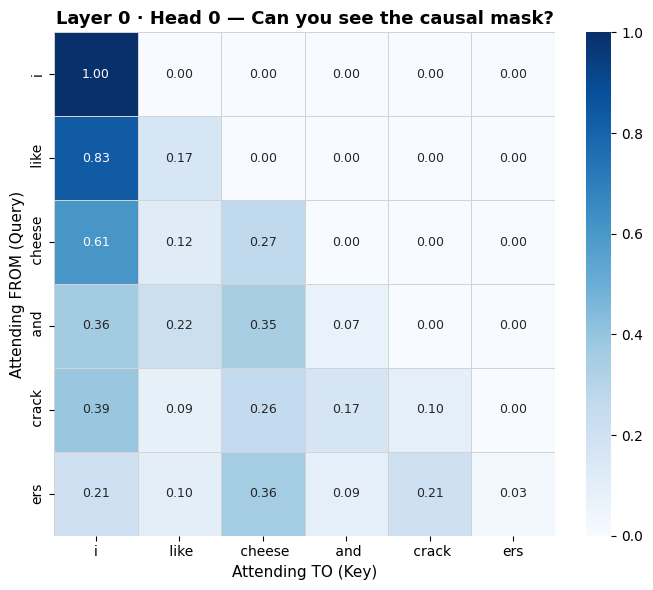

In [ ]:
def plot_attention_head(attentions, layer, head, tokens, title=None):
    # extracting [seq_len x seq_len] for this layer and head
    attn = attentions[layer][0, head].numpy()  # remove batch dim

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        attn,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 9}
    )
    ax.set_xlabel('Attending TO (Key)', fontsize=11)
    ax.set_ylabel('Attending FROM (Query)', fontsize=11)
    ax.set_title(title or f'Layer {layer} · Head {head}', fontsize=13, fontweight='bold')
    ax.xaxis.set_tick_params(rotation=0)
    plt.tight_layout()
    plt.show()

# plotting layer 0, head 0
plot_attention_head(attentions, layer=0, head=0, tokens=tokens,
                    title='Layer 0 · Head 0 — Can you see the causal mask?')

## comparing multiple heads in the same layer

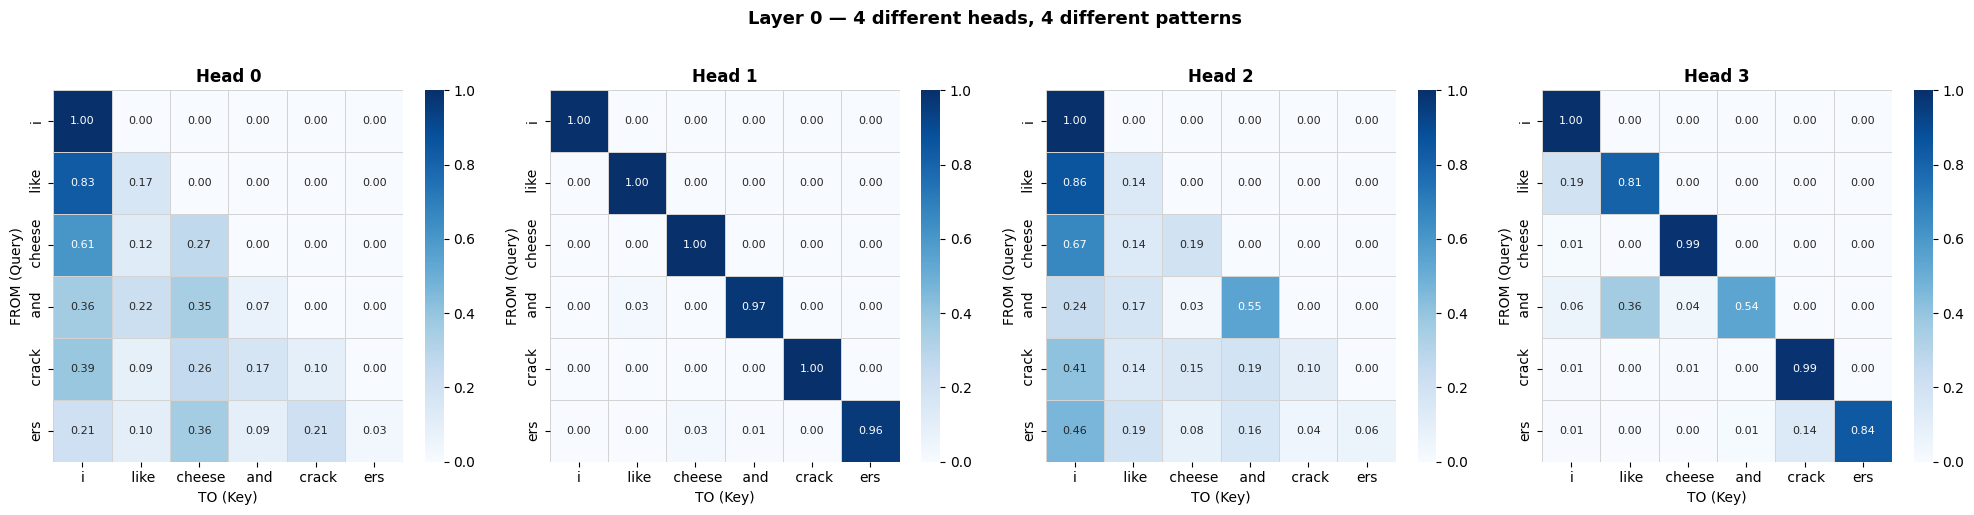

In [ ]:
def plot_multiple_heads(attentions, layer, heads, tokens):
    n = len(heads)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, head in zip(axes, heads):
        attn = attentions[layer][0, head].numpy()
        sns.heatmap(
            attn,
            xticklabels=tokens,
            yticklabels=tokens,
            cmap='Blues',
            vmin=0, vmax=1,
            linewidths=0.5,
            linecolor='lightgray',
            ax=ax,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 8}
        )
        ax.set_title(f'Head {head}', fontsize=12, fontweight='bold')
        ax.set_xlabel('TO (Key)')
        ax.set_ylabel('FROM (Query)')
        ax.xaxis.set_tick_params(rotation=0)

    fig.suptitle(f'Layer {layer} — 4 different heads, 4 different patterns',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_multiple_heads(attentions, layer=0, heads=[0, 1, 2, 3], tokens=tokens)

## early vs late layers

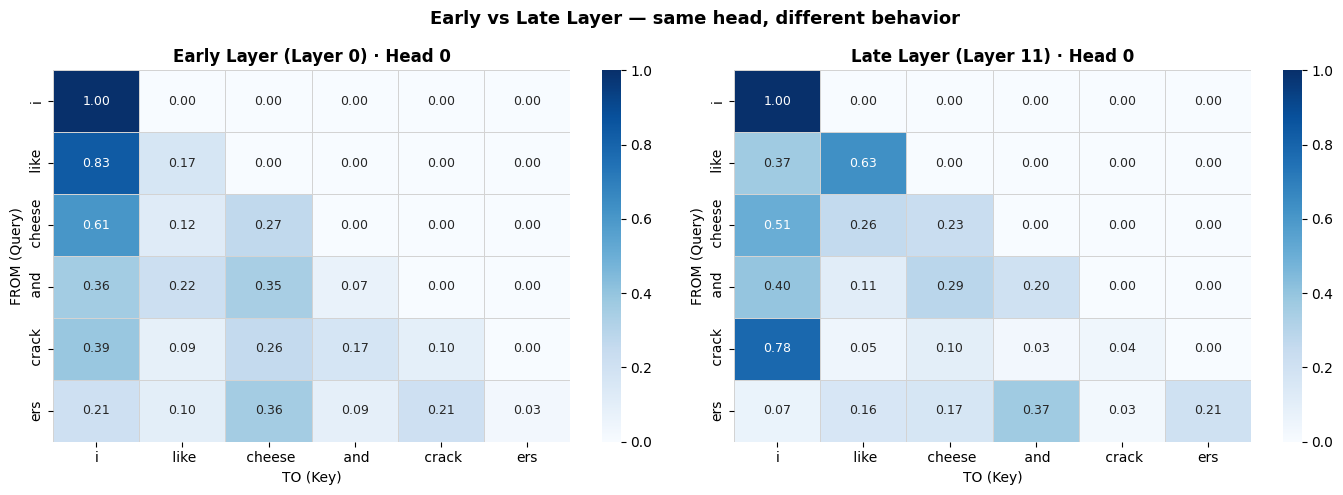

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, layer in zip(axes, [0, 11]):
    attn = attentions[layer][0, 0].numpy()  # head 0 in each layer
    sns.heatmap(
        attn,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 9}
    )
    label = 'Early' if layer == 0 else 'Late'
    ax.set_title(f'{label} Layer (Layer {layer}) · Head 0', fontsize=12, fontweight='bold')
    ax.set_xlabel('TO (Key)')
    ax.set_ylabel('FROM (Query)')
    ax.xaxis.set_tick_params(rotation=0)

plt.suptitle('Early vs Late Layer — same head, different behavior', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Tokens: ['ie', 'ee', ' ml', '/', 'ai', ' club', ' is', ' the', ' most', ' superior', ' club', ' at', ' r', 'ut', 'gers']



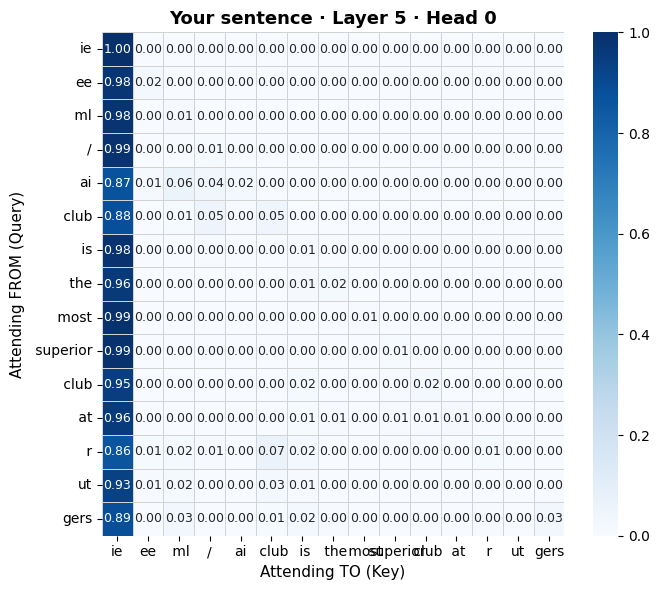

In [ ]:
my_sentence = "ieee ml/ai club is the most superior club at rutgers"

# tokenize and run forward pass
my_inputs    = tokenizer(my_sentence, return_tensors='pt')
my_tokens    = [tokenizer.decode([t]) for t in my_inputs['input_ids'][0]]

with torch.no_grad():
    my_outputs = model(**my_inputs)

my_attentions = my_outputs.attentions

print(f'Tokens: {my_tokens}')
print()

# visualize layer 5, head 0
plot_attention_head(my_attentions, layer=5, head=0, tokens=my_tokens,
                    title=f'Your sentence · Layer 5 · Head 0')

## attention highlighting by token
(html code generated by claude 🤓)

In [ ]:
def highlight_attention(
    attentions,
    tokens,
    source_token_idx,
    layer=0,
    head=0,
    color='59, 130, 246'
):
    """
    Render the sentence as colour-highlighted HTML.

    - Source token shown with a blue border
    - Past/present tokens shaded proportionally to attention weight
    - Future tokens greyed out (causal mask)
    """
    attn_matrix = attentions[layer][0, head].numpy()   # [seq, seq]
    attn_row    = attn_matrix[source_token_idx]         # [seq] — weights FROM source

    # Normalise so the brightest token = 1.0
    max_val  = attn_row.max()
    norm_row = attn_row / max_val if max_val > 0 else attn_row

    source_label = tokens[source_token_idx].strip()
    html = []

    # ── Outer card ──
    html.append(f'''
    <div style="
        font-family: Georgia, serif;
        background: #0f172a;
        border-radius: 16px;
        padding: 28px 32px;
        margin: 12px 0;
        box-shadow: 0 8px 32px rgba(0,0,0,0.5);
    ">
      <div style="color:#64748b; font-size:11px; letter-spacing:2px; text-transform:uppercase; margin-bottom:6px;">
        Layer {layer} &nbsp;·&nbsp; Head {head}
      </div>
      <div style="color:#e2e8f0; font-size:13px; margin-bottom:18px;">
        Attention FROM &nbsp;
        <span style="
            background: rgba({color},0.2);
            border: 1.5px solid rgba({color},0.9);
            border-radius:6px; padding:2px 10px;
            color:#bfdbfe; font-weight:bold; font-size:14px;
        ">«{source_label}»</span>
        &nbsp;→ TO each word
      </div>
      <div style="display:flex; flex-wrap:wrap; gap:8px; align-items:flex-end;">
    ''')

    for i, (token, weight) in enumerate(zip(tokens, norm_row)):
        alpha     = float(weight)
        raw_pct   = f'{attn_row[i]*100:.1f}%'
        is_source = (i == source_token_idx)
        is_future = (i > source_token_idx)
        tok_label = token.strip()

        if is_future:
            box_style = '''
                background: rgba(255,255,255,0.02);
                border: 1px dashed #1e293b;
                color: #1e3a5f;
                border-radius: 8px;
                padding: 10px 14px;
                font-size: 16px;
                text-align: center;
                min-width: 40px;
            '''
            badge = '<span style="display:block;font-size:9px;color:#1e3a5f;margin-top:3px;letter-spacing:1px;">masked</span>'

        elif is_source:
            box_style = f'''
                background: rgba({color},0.15);
                border: 2px solid rgba({color},1.0);
                color: #93c5fd;
                border-radius: 8px;
                padding: 10px 14px;
                font-size: 16px;
                font-weight: bold;
                text-align: center;
                min-width: 40px;
            '''
            badge = '<span style="display:block;font-size:9px;color:#60a5fa;margin-top:3px;letter-spacing:1px;">source</span>'

        else:
            text_col = '#ffffff' if alpha > 0.55 else ('#cbd5e1' if alpha > 0.2 else '#64748b')
            box_style = f'''
                background: rgba({color},{alpha:.3f});
                border: 1px solid rgba({color},{min(alpha+0.15,1.0):.3f});
                color: {text_col};
                border-radius: 8px;
                padding: 10px 14px;
                font-size: 16px;
                text-align: center;
                min-width: 40px;
            '''
            badge = f'<span style="display:block;font-size:9px;color:#94a3b8;margin-top:3px;">{raw_pct}</span>'

        html.append(f'<div style="{box_style}" title="raw attn: {attn_row[i]:.4f}">{tok_label}{badge}</div>')

    # ── Legend ──
    swatches = ''.join([
        f'<div style="width:22px;height:12px;border-radius:3px;background:rgba({color},{v:.1f});"></div>'
        for v in [0.08, 0.25, 0.45, 0.65, 0.85]
    ])
    html.append(f'''
      </div>
      <div style="margin-top:20px;display:flex;align-items:center;gap:6px;">
        <span style="color:#475569;font-size:11px;">Less</span>
        {swatches}
        <span style="color:#475569;font-size:11px;">More attention</span>
        &nbsp;&nbsp;
        <div style="width:22px;height:12px;border-radius:3px;border:1px dashed #1e293b;"></div>
        <span style="color:#475569;font-size:11px;">Causal mask (future)</span>
      </div>
    </div>
    ''')

    display(HTML(''.join(html)))


print('highlight_attention() is ready!')
print(f'Tokens: {list(enumerate(tokens))}')

highlight_attention() is ready!
Tokens: [(0, 'i'), (1, ' like'), (2, ' cheese'), (3, ' and'), (4, ' crack'), (5, 'ers')]


In [ ]:
# When GPT-2 processes "sat" (index 2), what does it look at?
highlight_attention(attentions, tokens, source_token_idx=2, layer=0, head=0)

In [ ]:
# Same token, different head — notice the pattern changes completely
highlight_attention(attentions, tokens, source_token_idx=2, layer=0, head=3)

In [ ]:
# Same token, deeper layer — richer, more global attention
highlight_attention(attentions, tokens, source_token_idx=2, layer=11, head=0)

## try your own sentenceeee

In [ ]:
my_sentence = "machine learning is really cool"
source_idx  = 4    # which token is doing the looking? (0 = first token)
my_layer    = 5    # 0–11
my_head     = 0    # 0–11

my_inputs = tokenizer(my_sentence, return_tensors='pt')
my_tokens = [tokenizer.decode([t]) for t in my_inputs['input_ids'][0]]

with torch.no_grad():
    my_outputs = model(**my_inputs)

print(f'Tokens: {list(enumerate(my_tokens))}')
highlight_attention(my_outputs.attentions, my_tokens, source_idx, my_layer, my_head)

Tokens: [(0, 'machine'), (1, ' learning'), (2, ' is'), (3, ' really'), (4, ' cool')]
